# 02 — RUL Baseline Model (RandomForest, FD001)

**Independent R&D prototype on public NASA data.** Metrics and figures below are regenerated from the artifacts written by `src/models/train_baseline.py`.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.width", 120)
print("repo root:", ROOT)

repo root: /home/lu2/dev/personal/projects/learning/genai-condition-monitoring-prototype


In [2]:
import json
from src.models.train_baseline import train_and_evaluate
proc = ROOT / 'data' / 'processed'
metrics_path = ROOT / 'reports' / 'metrics_model.json'
if not (proc / 'test_predictions.csv').exists():
    train_and_evaluate()
metrics = json.loads(metrics_path.read_text())
print('model      :', metrics['model'])
print('rul_cap    :', metrics['rul_cap'])
print('test units :', metrics['n_test_units'])
print('vs capped   truth:', metrics['metrics_vs_capped_truth'])
print('vs uncapped truth:', metrics['metrics_vs_uncapped_truth'])

model      : RandomForestRegressor
rul_cap    : 125
test units : 100
vs capped   truth: {'rmse': 17.1989, 'mae': 12.0709, 'r2': 0.8158}
vs uncapped truth: {'rmse': 18.1877, 'mae': 13.1409, 'r2': 0.8084}


## Predictions and risk bands

Each test unit is scored at its **last** recorded cycle. `risk_band` is derived from predicted RUL: high ≤ 30 < medium ≤ 80 < low.

In [3]:
preds = pd.read_csv(proc / 'test_predictions.csv')
print('rows:', len(preds), '| bands:', preds.risk_band.value_counts().to_dict())
preds.head()

rows: 100 | bands: {'low': 60, 'medium': 22, 'high': 18}


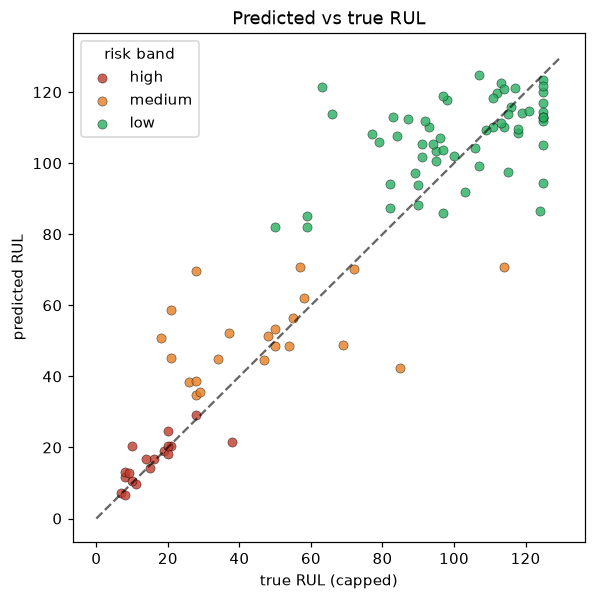

In [4]:
# Predicted vs true (capped), coloured by risk band.
cap = metrics['rul_cap']
tc = preds.true_rul.clip(upper=cap)
colors = {'high':'#c0392b','medium':'#e67e22','low':'#27ae60'}
fig, ax = plt.subplots(figsize=(6,6))
for b,c in colors.items():
    m = preds.risk_band == b
    ax.scatter(tc[m], preds.pred_rul[m], c=c, label=b, edgecolor='k', linewidth=.3, alpha=.8)
lim = max(tc.max(), preds.pred_rul.max())+5
ax.plot([0,lim],[0,lim],'k--',alpha=.6)
ax.set_xlabel('true RUL (capped)'); ax.set_ylabel('predicted RUL')
ax.set_title('Predicted vs true RUL'); ax.legend(title='risk band')
None

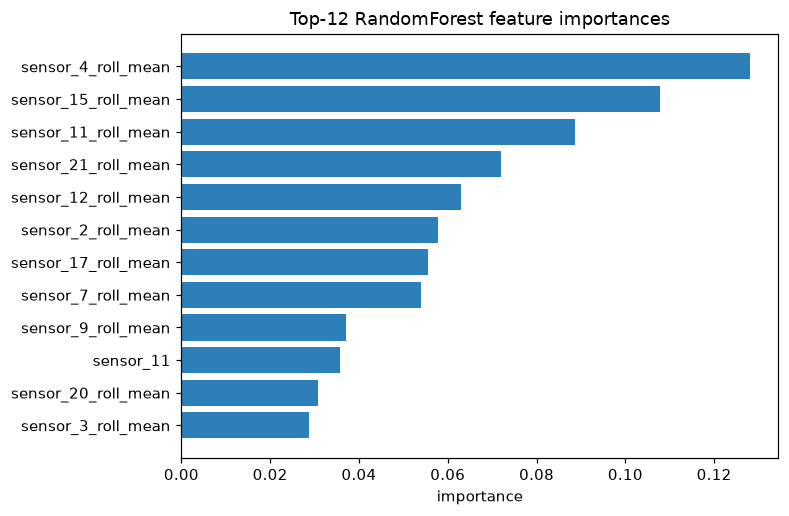

In [5]:
# Feature importances (top 12).
fi = pd.read_csv(proc / 'feature_importances.csv').head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7,5))
ax.barh(fi.feature, fi.importance, color='#2c7fb8')
ax.set_xlabel('importance'); ax.set_title('Top-12 RandomForest feature importances')
None

## Highest-error units

Full write-up in `reports/error_analysis.md`. The largest residuals are optimistic over-predictions on mid-life units — the operationally risky direction, which is why the deployment story keeps a human in the loop.

In [6]:
preds['abs_err'] = (preds.pred_rul - preds.true_rul).abs()
preds.sort_values('abs_err', ascending=False).head(5)

**Bottom line.** A plain RandomForest on 14 informative sensors + short rolling stats reaches RMSE ≈ 17 (capped truth) on FD001 test — a credible, honest baseline, not a tuned SOTA model. Limitations and next steps: `reports/error_analysis.md` and `docs/data-sources.md`.